# Canonical Correlation Analysis (CCorA)

## Overview
Canonical Correlation Analysis (CCorA) examines the relationships between **two sets of variables** measured on the same sampling units. It finds pairs of linear combinations — one from each set — that are maximally correlated.

**Key distinction from other methods:**

| Method | Question | Response structure |
|---|---|---|
| Multiple regression | How do Xs predict one Y? | One Y, many Xs |
| MANOVA/LDA | Do groups differ on many Ys? | Many Ys, one categorical X |
| RDA | How do env variables drive species? | Many Ys, many Xs (asymmetric) |
| **CCorA** | How are two variable sets related? | Many Ys ↔ Many Xs (symmetric) |

**Ecological examples:** morphometric measurements vs. life-history traits; physical vs. chemical environment variables; diet composition vs. physiology.

**Naming caution:** in ecology, "CCA" almost always means Canonical Correspondence Analysis (a constrained ordination for species data). CCorA is a different technique entirely. This notebook covers CCorA.

**Reference:** Quinn & Keough (2002) ch. 17

---

In [1]:
library(tidyverse); library(CCA); library(vegan); library(CCP)
set.seed(31)
# 50 fish: Set 1 = morphology (4 vars), Set 2 = physiology (3 vars)
# True relationship: large fish have higher metabolic rates
n <- 50
size_factor <- rnorm(n, 0, 1)

morphology <- data.frame(
  total_length  = 25 + 4 * size_factor + rnorm(n, 0, 0.8),
  body_depth    = 8  + 1.5 * size_factor + rnorm(n, 0, 0.5),
  head_width    = 5  + 1.2 * size_factor + rnorm(n, 0, 0.4),
  tail_length   = 6  + 0.8 * size_factor + rnorm(n, 0, 0.6)
)

physiology <- data.frame(
  metabolic_rate  = 80 + 10 * size_factor + rnorm(n, 0, 3),
  gill_area       = 12 +  2 * size_factor + rnorm(n, 0, 1),
  oxygen_uptake   = 5  +  1 * size_factor + rnorm(n, 0, 0.8)
)

cat("Dataset: n =", n, "fish\n")
cat("Set 1 (morphology):", ncol(morphology), "variables\n")
cat("Set 2 (physiology):", ncol(physiology), "variables\n")

# Scale both sets
X <- scale(morphology)
Y <- scale(physiology)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'CCA' was built under R version 4.4.3"
Loading required package: fda

Loading required package: splines

Lo

Dataset: n = 50 fish
Set 1 (morphology): 4 variables
Set 2 (physiology): 3 variables


---
## Correlation structure between sets

In [2]:
# Examine between-set correlations
cat("--- Cross-correlation matrix (morphology vs physiology) ---\n")
cross_cor <- cor(X, Y)
print(round(cross_cor, 3))
cat("\nWithin-set correlations for X (morphology):\n")
print(round(cor(X), 3))
cat("\nWithin-set correlations for Y (physiology):\n")
print(round(cor(Y), 3))

--- Cross-correlation matrix (morphology vs physiology) ---
             metabolic_rate gill_area oxygen_uptake
total_length          0.916     0.897         0.743
body_depth            0.881     0.853         0.638
head_width            0.876     0.821         0.737
tail_length           0.758     0.645         0.571

Within-set correlations for X (morphology):
             total_length body_depth head_width tail_length
total_length        1.000      0.940      0.917       0.789
body_depth          0.940      1.000      0.880       0.783
head_width          0.917      0.880      1.000       0.727
tail_length         0.789      0.783      0.727       1.000

Within-set correlations for Y (physiology):
               metabolic_rate gill_area oxygen_uptake
metabolic_rate          1.000     0.853         0.722
gill_area               0.853     1.000         0.696
oxygen_uptake           0.722     0.696         1.000


In [3]:
# Canonical Correlation Analysis using CCA package
cc_fit <- cc(X, Y)

cat("=== Canonical correlations ===\n")
for (i in seq_along(cc_fit$cor))
  cat(sprintf("  Pair %d: r_c = %.4f (r² = %.4f)\n",
              i, cc_fit$cor[i], cc_fit$cor[i]^2))

# Canonical loadings (structure coefficients)
cat("\n--- Canonical loadings: Set X (morphology) ---\n")
print(round(cc_fit$scores$corr.X.xscores, 3))
cat("\n--- Canonical loadings: Set Y (physiology) ---\n")
print(round(cc_fit$scores$corr.Y.yscores, 3))
cat("(Loadings ≥ |0.30| typically interpreted as meaningful)\n")

=== Canonical correlations ===
  Pair 1: r_c = 0.9478 (r² = 0.8983)
  Pair 2: r_c = 0.3914 (r² = 0.1532)
  Pair 3: r_c = 0.3143 (r² = 0.0988)

--- Canonical loadings: Set X (morphology) ---
               [,1]   [,2]   [,3]
total_length -0.998 -0.016  0.009
body_depth   -0.946 -0.226 -0.223
head_width   -0.941  0.199 -0.076
tail_length  -0.778  0.195 -0.508

--- Canonical loadings: Set Y (physiology) ---
                 [,1]   [,2]   [,3]
metabolic_rate -0.970  0.060 -0.234
gill_area      -0.947 -0.231  0.224
oxygen_uptake  -0.788  0.527  0.318
(Loadings ≥ |0.30| typically interpreted as meaningful)


---
## Significance testing and redundancy

In [4]:
# Wilks' Lambda test for each canonical pair
# Tests H0: remaining canonical correlations are all zero
cat("--- Wilks' Lambda significance tests ---\n")
cc_test <- p.asym(cc_fit$cor, n, ncol(X), ncol(Y), tstat = "Wilks")
print(cc_test)
cat("Interpret sequentially: first test includes all pairs,\n")
cat("subsequent tests drop the largest pair one at a time.\n")

--- Wilks' Lambda significance tests ---
Wilks' Lambda, using F-approximation (Rao's F):
               stat    approx df1      df2    p.value
1 to 3:  0.07758477 15.473961  12 114.0588 0.00000000
2 to 3:  0.76320160  2.121829   6  88.0000 0.05858954
3 to 3:  0.90122984  2.465884   2  45.0000 0.09633857
$id
[1] "Wilks"

$stat
[1] 0.07758477 0.76320160 0.90122984

$approx
[1] 15.473961  2.121829  2.465884

$df1
[1] 12  6  2

$df2
[1] 114.0588  88.0000  45.0000

$p.value
[1] 0.00000000 0.05858954 0.09633857

Interpret sequentially: first test includes all pairs,
subsequent tests drop the largest pair one at a time.


--- Redundancy index (Stewart-Love) ---
Proportion of Y variance explained by each canonical variate:
  (colMeans of squared canonical loadings × r_c²)
  Pair 1: 0.737 (73.7%)
  Pair 2: 0.017 (1.7%)
  Pair 3: 0.007 (0.7%)
Total redundancy (Y given X): 0.76 


`geom_smooth()` using formula = 'y ~ x'


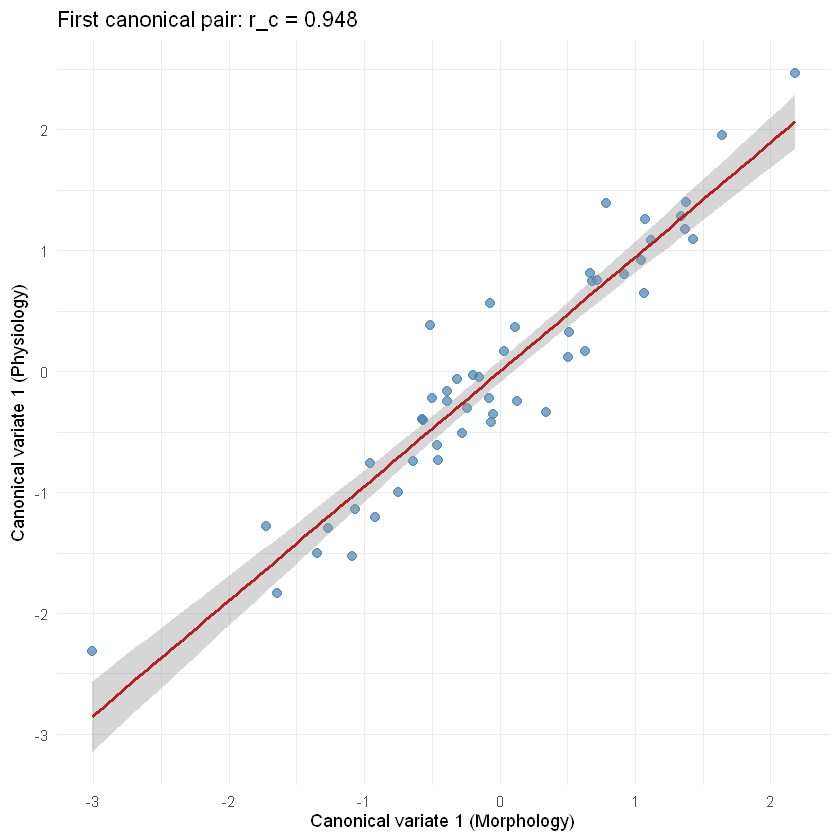

In [5]:
# Redundancy analysis: proportion of variance in each set
# explained by the canonical variates of the OTHER set
cat("--- Redundancy index (Stewart-Love) ---\n")
cc_sum <- comput(X, Y, cc_fit)

# Variance explained in Y by X's canonical variates
prop_var_Y <- cc_sum$corr.Y.yscores^2  # squared loadings
prop_shared <- sweep(prop_var_Y, 2, cc_fit$cor^2, "*")
cat("Proportion of Y variance explained by each canonical variate:\n")
cat("  (colMeans of squared canonical loadings × r_c²)\n")
redund_Y <- colMeans(prop_var_Y) * cc_fit$cor^2
for (i in seq_along(redund_Y))
  cat(sprintf("  Pair %d: %.3f (%.1f%%)\n", i, redund_Y[i], redund_Y[i]*100))
cat("Total redundancy (Y given X):", round(sum(redund_Y), 3), "\n")

# Biplot of first canonical pair
scores_X <- cc_fit$scores$xscores
scores_Y <- cc_fit$scores$yscores
plot_df <- data.frame(
  CV1_X = scores_X[, 1], CV1_Y = scores_Y[, 1],
  CV2_X = scores_X[, 2], CV2_Y = scores_Y[, 2]
)
ggplot(plot_df, aes(CV1_X, CV1_Y)) +
  geom_point(alpha = 0.7, colour = "steelblue", size = 2.5) +
  geom_smooth(method = "lm", se = TRUE, colour = "firebrick", linewidth = 0.9) +
  labs(title = sprintf("First canonical pair: r_c = %.3f", cc_fit$cor[1]),
       x = "Canonical variate 1 (Morphology)",
       y = "Canonical variate 1 (Physiology)") +
  theme_minimal()

---
## Common Pitfalls

**1. Confusing CCorA with Canonical Correspondence Analysis**
In ecology, "CCA" invariably means Canonical Correspondence Analysis (chi-square-based constrained ordination for species data, available in `vegan::cca()`). CCorA is a different method for relating two continuous variable sets symmetrically. The naming confusion is pervasive — be explicit when writing up results.

**2. Interpreting canonical correlations without checking redundancy**
A high canonical correlation does not mean each set is well explained by the other. Redundancy (Stewart-Love index) measures the average variance in one set explained by the canonical variates derived from the other. A high r_c with low redundancy means only a small portion of each set is actually accounted for.

**3. Over-interpreting non-significant canonical pairs**
Only the first (or first few) canonical pairs are usually significant. Non-significant pairs represent noise. Use the sequential Wilks' lambda test and interpret only significant pairs.

**4. Using raw canonical coefficients instead of structure loadings**
Like in LDA, raw canonical coefficients are affected by multicollinearity within sets. Use canonical loadings (correlations between original variables and canonical variates) — these are more stable and interpretable.

**5. Applying CCorA with more variables than observations**
CCorA requires inverting within-set covariance matrices. With p + q ≥ n, this fails. Reduce dimensionality first (PCA, variable selection) before applying CCorA.

**6. Symmetric framing when the scientific question is asymmetric**
If you have a clear response set (e.g., species community) and predictor set (e.g., environmental variables), RDA is more appropriate than CCorA because it imposes the predictor-response asymmetry that matches the biological question. CCorA is appropriate when both variable sets are genuinely co-equal (e.g., morphology vs. physiology measured on the same individuals).


---
*r_methods_library - Samantha McGarrigle*